# 10 -- A Learned CrowdRL Policy as a JuPedSim Operational Model

This notebook recreates the flow of JuPedSim's
[getting started guide](https://www.jupedsim.org/stable/notebooks/getting_started.html),
with one substitution: instead of a built-in operational model (e.g. the
Collision Free Speed Model), the agents are driven by a **trained CrowdRL
policy** deployed through `crowdrl_jupedsim.LearnedPolicyModel`.

The policy artefact is the repo's `example_model/policy_r0400.onnx` -- a
**self-describing** ONNX (issue #7): its resolved observation/action configs
and provenance are embedded in the file's metadata, so the adapter needs no
hand-supplied configuration at all.

Scenarios (the same two the e2e test `tests/test_e2e_jupedsim_trained_policy.py`
pins):

1. **Corner** -- the L-corridor from
   [jupedsim#1625](https://github.com/PedestrianDynamics/jupedsim/issues/1625):
   agents must follow the routed waypoint around a bend they cannot see the
   goal through.
2. **Bottleneck** -- 12 agents through a 1.4 m aperture: crowd behaviour,
   not just solo navigation.

Requirements: a JuPedSim 2.0 source build on `sys.path` (the custom-model
layer is not on PyPI -- see `plan/handover_2026-07-29.md` for the local
wiring) plus the `dev` extra (`pedpy`, `plotly`) for the animation.

In [1]:
from pathlib import Path
import sys

# JuPedSim 2.0 comes from a local source build. If a plain import fails,
# fall back to the known local build paths (machine-specific wiring).
try:
    import jupedsim as jps
except ImportError:
    _JPS = Path("/home/fabi/dev/jupedsim")
    sys.path[:0] = [
        str(_JPS / "python_modules" / "jupedsim"),
        str(_JPS / "build-py312" / "lib"),
    ]
    import jupedsim as jps

import shapely
import plotly.io as pio
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

from crowdrl_jupedsim import CrowdRLAgentState, LearnedPolicyModel, OnnxPolicy

# notebook_utils pins the renderer for the jupedsim.org docs build; the plain
# mimetype renderer keeps outputs small and renders in VS Code / JupyterLab.
pio.renderers.default = "plotly_mimetype"

print("jupedsim", jps.__version__)

jupedsim 2.0.0


## The self-describing policy

`OnnxPolicy` reads the training configuration back out of the artefact.
Nothing below is typed in by hand -- and if we *did* pass an explicit config
that disagrees with the embedded record, construction would raise.

In [2]:
POLICY_PATH = Path("..") / "example_model" / "policy_r0400.onnx"

policy = OnnxPolicy(POLICY_PATH)
meta = policy.metadata
print("obs_dim:", meta.obs_dim, "| action_dim:", meta.action_dim)
print("provenance:", meta.provenance)
print(
    "use_goal_direction =", meta.obs_config.use_goal_direction,
    "-> the policy navigates by the routed next waypoint alone",
)

obs_dim: 89 | action_dim: 4
provenance: {'run': 'results_exp_nogoaldir_stable_bigrooms_density_v4', 'checkpoint': 'checkpoint_rollout_0400.pt', 'rollout': 31398, 'git_rev': '701a41d', 'source': 'scripts/reexport_onnx.py'}
use_goal_direction = False -> the policy navigates by the routed next waypoint alone


In [3]:
OUT_DIR = Path("outputs/10_jupedsim")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def run_scenario(name, area, exit_polygon, spawns, max_steps=6000, **model_kwargs):
    """Run the learned model in JuPedSim, recording trajectories to sqlite.

    Mirrors the getting-started loop: build the simulation with a
    SqliteTrajectoryWriter (records every 4th frame -> 25 fps at dt=0.01),
    add an exit stage + journey, spawn agents, iterate until everyone left.
    """
    trajectory_file = OUT_DIR / f"{name}.sqlite"
    trajectory_file.unlink(missing_ok=True)

    # Self-configured from the artefact's metadata; passing the walkable
    # geometry activates training-parity contact physics (agent-agent
    # contact forces + body-clearance wall projection).
    model = LearnedPolicyModel(
        OnnxPolicy(POLICY_PATH), walkable_geometry=area, **model_kwargs
    )
    simulation = jps.Simulation(
        model=model,
        geometry=area,
        dt=0.01,
        trajectory_writer=jps.SqliteTrajectoryWriter(output_file=trajectory_file),
    )
    exit_id = simulation.add_exit_stage(exit_polygon)
    journey_id = simulation.add_journey(jps.JourneyDescription([exit_id]))
    for position in spawns:
        simulation.add_agent(
            journey_id=journey_id,
            stage_id=exit_id,
            state=CrowdRLAgentState(position=position),
        )

    n = simulation.agent_count()
    while simulation.agent_count() > 0 and simulation.iteration_count() < max_steps:
        simulation.iterate()

    print(
        f"{name}: {n - simulation.agent_count()}/{n} agents exited in "
        f"{simulation.iteration_count() * 0.01:.1f} s simulated time"
    )
    return trajectory_file

## Scenario 1 -- the corner (jupedsim#1625 geometry)

An L-shaped corridor: the exit is around a bend, so the straight line to the
goal points through a wall. Before JuPedSim exposed the routed waypoint
(`ped.next_target`, merged in
[PR #1626](https://github.com/PedestrianDynamics/jupedsim/pull/1626)), a
Python model only saw the final goal here -- every agent walked into the
corner wall and pinned. Now the policy receives the waypoint through the
navmesh observation block and rounds the bend.

In [4]:
CORNER_AREA = shapely.Polygon(
    [(0, 0), (12, 0), (12, 12), (10, 12), (10, 2), (0, 2)]
)
CORNER_EXIT = [(10, 11), (12, 11), (12, 12), (10, 12)]
CORNER_SPAWNS = [(1.5, 1.0), (3.0, 1.2), (4.5, 0.8), (6.0, 1.0)]

corner_file = run_scenario("corner", CORNER_AREA, CORNER_EXIT, CORNER_SPAWNS, max_steps=4000)
trajectory_data, walkable_area = read_sqlite_file(corner_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

corner: 4/4 agents exited in 13.2 s simulated time


## Scenario 2 -- bottleneck (12 agents, 1.4 m aperture)

An hourglass room pinched to a 1.4 m opening -- mid-range of the tier-1
training distribution. This probes crowd behaviour rather than solo
navigation: queueing, merging and flow through the neck.

With training-parity contact physics active (the `walkable_geometry`
argument), agents can no longer pass through each other: a real queue
forms at the neck. Observed here: all 12 agents exit in ~30 s of
simulated time with a minimum centre-to-centre distance of ~0.29 m
(head-on body contact is 0.30 m; pre-physics this bottomed out at
~0.04 m). Note the honest trade-off: hard contact turns ghosting into
queueing, and the resulting bottleneck throughput sits below the
empirical range -- a policy-behaviour question (yielding, dense
packing) rather than an adapter one, consistent with the known
high-density weaknesses of the current checkpoints.

In [5]:
import numpy as np

BOTTLENECK_AREA = shapely.Polygon(
    [
        (0, 0), (6.8, 0), (6.8, 4.3), (7.2, 4.3), (7.2, 0), (14, 0),
        (14, 10), (7.2, 10), (7.2, 5.7), (6.8, 5.7), (6.8, 10), (0, 10),
    ]
)
BOTTLENECK_EXIT = [(13.0, 4.0), (14.0, 4.0), (14.0, 6.0), (13.0, 6.0)]

rng = np.random.default_rng(7)
BOTTLENECK_SPAWNS = [
    (float(x), float(y))
    for x, y in zip(rng.uniform(1.0, 5.5, 12), rng.uniform(1.5, 8.5, 12))
]

bottleneck_file = run_scenario(
    "bottleneck", BOTTLENECK_AREA, BOTTLENECK_EXIT, BOTTLENECK_SPAWNS
)
trajectory_data, walkable_area = read_sqlite_file(bottleneck_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

bottleneck: 12/12 agents exited in 30.3 s simulated time


## Notes

- The whole deployment surface used here is two calls:
  `LearnedPolicyModel(OnnxPolicy(path), walkable_geometry=area)` and the
  standard JuPedSim
  simulation loop. Everything else (observation assembly, raycasts,
  temporal memory, action interpretation, integration) lives inside the
  operational model and reuses the exact crowdrl-core code from training.
- The same scenarios are pinned as tests in
  `tests/test_e2e_jupedsim_trained_policy.py`; run them with the jupedsim
  build on `PYTHONPATH`.
- Colour in the animation encodes each agent's current speed (pedpy's
  individual-speed computation, as in the JuPedSim docs).

## Behavioural parity: JuPedSim deployment vs CrowdRL native

The transfer guarantee is tested numerically at the observation level (the
obs-parity harness), but the end-to-end question is behavioural: **does the
same policy, in the same geometry, from the same spawns, produce roughly the
same simulation in JuPedSim as in CrowdRL's own pipeline?** This mirrors the
experimental-vs-simulated comparison in JuPedSim's getting-started guide,
with CrowdRL-native taking the role of the reference.

Both sides below run the corner scenario with the run's *trained* dynamics
(`desired_velocity_weight = 0.8` from `config_resolved.yaml` -- note this
env-level parameter does not travel in the ONNX metadata, which only covers
obs/action configs; the adapter default is a smoother 0.05). The native side
is a faithful re-implementation of `CrowdEnv.step` on the same crowdrl-core
functions: navmesh waypoint + true path deviation, batched observations,
identical contact physics, and jupedsim's removal rule (inside the exit
polygon) for comparability.

Two deployment-side deltas are known and intentional: the waypoint comes
from JuPedSim's router instead of the crowdrl navmesh funnel, and
`path_deviation` is 0.0 (single-waypoint contract).

In [6]:
import pandas as pd
import pedpy

from crowdrl_core.action import interpret_actions_batch
from crowdrl_core.collision import (
    compute_contact_forces,
    detect_collisions,
    enforce_wall_boundaries,
)
from crowdrl_core.geometry import build_navmesh, extract_wall_segments
from crowdrl_core.observation import build_observations_batch
from crowdrl_core.world_state import WorldState

W_TRAINED = 0.8  # desired_velocity_weight from the run's config_resolved.yaml
GOAL = np.array([11.0, 11.5])  # jupedsim's final_target: the exit centroid


def run_native_corner(w=W_TRAINED, max_steps=4000):
    """CrowdRL-native corner sim: CrowdEnv.step semantics on crowdrl-core."""
    policy = OnnxPolicy(POLICY_PATH)
    oc, ac = policy.metadata.obs_config, policy.metadata.action_config
    n = len(CORNER_SPAWNS)

    world = WorldState(
        positions=np.array(CORNER_SPAWNS, dtype=np.float64),
        velocities=np.zeros((n, 2)),
        torso_orientations=np.zeros(n),
        head_orientations=np.zeros(n),
        shoulder_widths=np.full(n, 0.225),
        chest_depths=np.full(n, 0.15),
        masses=np.full(n, 80.0),
        goal_positions=np.tile(GOAL, (n, 1)),
        walkable_polygon=CORNER_AREA,
        wall_segments=extract_wall_segments(CORNER_AREA),
        navmesh=build_navmesh(CORNER_AREA),
        active_mask=np.ones(n, dtype=np.bool_),
    )
    world.preferred_speeds = np.full(n, 1.34)
    # Temporal-memory init, mirroring CrowdEnv.reset.
    buf = oc.temporal_memory_window + 1
    g0 = np.linalg.norm(world.goal_positions - world.positions, axis=1)
    world.spawn_positions = world.positions.copy()
    world.initial_goal_distances = g0.copy()
    world.cumulative_path_length = np.zeros(n)
    world.pos_history = np.broadcast_to(world.positions[:, None, :], (n, buf, 2)).copy()
    world.gdist_history = np.broadcast_to(g0[:, None], (n, buf)).copy()
    world.step_count = 0

    exit_poly = shapely.Polygon(CORNER_EXIT)
    active = world.active_mask
    trajectory = [world.positions.copy()]
    exits = {}
    for step in range(1, max_steps + 1):
        prev_pos, prev_act = world.positions.copy(), active.copy()
        obs = build_observations_batch(world, oc)
        actions = np.stack([policy(obs[i]) for i in range(n)])
        actions[~active] = 0.0
        batch = interpret_actions_batch(
            actions,
            world.torso_orientations,
            world.torso_orientations,
            world.head_orientations,
            ac,
            current_speeds=np.linalg.norm(world.velocities, axis=1),
        )
        world.velocities[active] = (
            w * batch.desired_velocities[active] + (1.0 - w) * world.velocities[active]
        )
        world.torso_orientations[active] = batch.new_torso_orientations[active]
        world.head_orientations[active] = batch.new_head_orientations[active]
        accel = compute_contact_forces(world, collisions=detect_collisions(world))
        world.velocities[active] += accel[active] * 0.01
        sp = np.linalg.norm(world.velocities[active], axis=1)
        fast = sp > 5.0
        if np.any(fast):
            world.velocities[active] *= np.where(fast, 5.0 / np.maximum(sp, 1e-10), 1.0)[:, None]
        world.positions[active] += world.velocities[active] * 0.01
        enforce_wall_boundaries(world)
        for i in range(n):
            if active[i] and exit_poly.contains(shapely.Point(world.positions[i])):
                active[i] = False
                exits[i] = step
                world.velocities[i] = 0.0
        world.active_mask = active
        d = np.linalg.norm(world.positions - prev_pos, axis=1)
        world.cumulative_path_length += np.where(prev_act, d, 0.0)
        wi = (step - 1) % buf
        world.pos_history[:, wi, :] = world.positions
        world.gdist_history[:, wi] = np.linalg.norm(
            world.goal_positions - world.positions, axis=1
        )
        world.step_count = step
        trajectory.append(world.positions.copy())
        if not np.any(active):
            break
    return np.asarray(trajectory), exits


def native_to_pedpy(trajectory, exits, every=4):
    """Native (T, n, 2) trajectory -> pedpy TrajectoryData (25 fps like the
    sqlite writer). Agents disappear from the frame after exiting."""
    rows = []
    n = trajectory.shape[1]
    for t in range(0, len(trajectory), every):
        for i in range(n):
            if i in exits and t > exits[i]:
                continue
            rows.append((i, t // every, trajectory[t, i, 0], trajectory[t, i, 1]))
    df = pd.DataFrame(rows, columns=["id", "frame", "x", "y"])
    return pedpy.TrajectoryData(data=df, frame_rate=25)


native_traj, native_exits = run_native_corner()
print(f"native exits (s): {[round(native_exits[i] * 0.01, 2) for i in sorted(native_exits)]}")

native exits (s): [10.82, 10.12, 9.23, 8.5]


corner_parity: 3/4 agents exited in 40.0 s simulated time


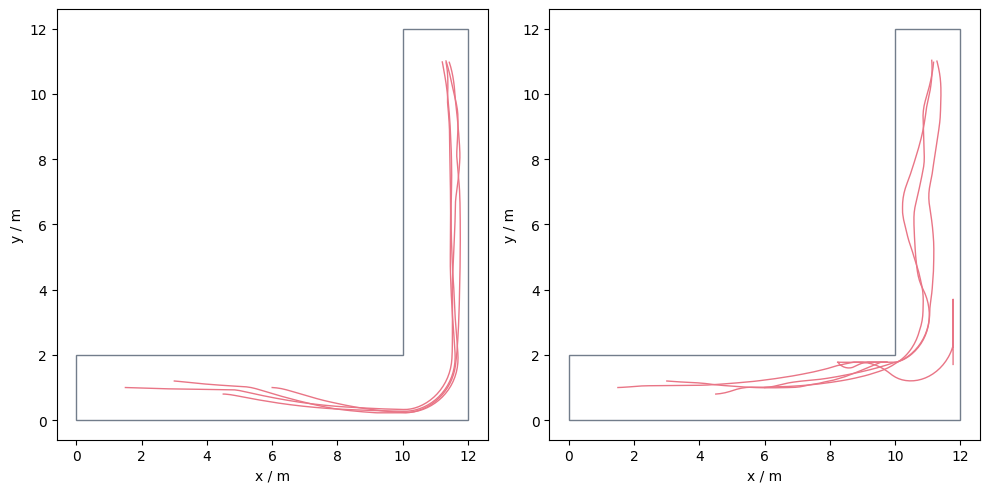

In [7]:
# JuPedSim side at the same trained dynamics, recorded to sqlite as usual.
parity_file = run_scenario(
    "corner_parity",
    CORNER_AREA,
    CORNER_EXIT,
    CORNER_SPAWNS,
    max_steps=4000,
    desired_velocity_weight=W_TRAINED,
)
jps_traj_data, jps_walkable = read_sqlite_file(parity_file)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, aspect="equal")
ax1.set_title("CrowdRL native")
pedpy.plot_trajectories(
    traj=native_to_pedpy(native_traj, native_exits),
    axes=ax1,
    walkable_area=pedpy.WalkableArea(CORNER_AREA),
)
ax2 = fig.add_subplot(122, aspect="equal")
ax2.set_title("JuPedSim deployment")
pedpy.plot_trajectories(traj=jps_traj_data, axes=ax2, walkable_area=jps_walkable)
plt.tight_layout()
plt.show()

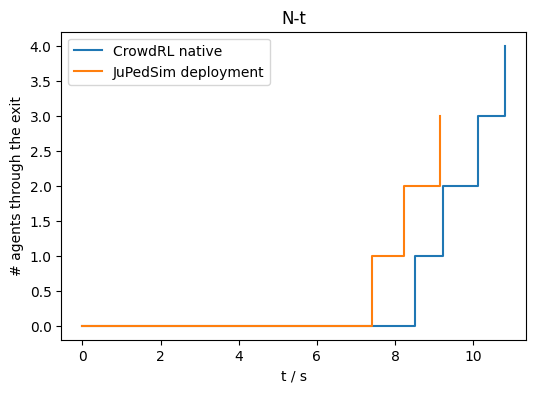

agent 0: native exit 10.82s | deviation mean 2.76 m, max 7.31 m
agent 1: native exit 10.12s | deviation mean 1.37 m, max 2.18 m
agent 2: native exit  9.23s | deviation mean 1.57 m, max 2.31 m
agent 3: native exit  8.50s | deviation mean 1.69 m, max 2.20 m


In [8]:
# N-t comparison (cumulative agents through the exit) + per-agent deviation.
jps_frames = jps_traj_data.data.groupby("id")["frame"].max()
jps_exit_times = sorted(jps_frames[jps_frames < jps_frames.max()].to_list())
# An agent alive until the recording's final frame never exited.
n_agents = len(CORNER_SPAWNS)

fig, ax = plt.subplots(figsize=(6, 4))
for label, times in (
    ("CrowdRL native", sorted(t * 0.01 for t in native_exits.values())),
    ("JuPedSim deployment", [f / 25.0 for f in jps_exit_times]),
):
    ax.step([0.0] + list(times), range(len(times) + 1), where="post", label=label)
ax.set_xlabel("t / s")
ax.set_ylabel("# agents through the exit")
ax.set_title("N-t")
ax.legend()
plt.show()

# Position deviation per agent while both simulations still track it.
jps_by_id = {i: g.sort_values("frame")[["x", "y"]].to_numpy() for i, g in jps_traj_data.data.groupby("id")}
for idx, (jid, jtraj) in enumerate(sorted(jps_by_id.items())):
    native_frames = native_traj[::4, idx, :]
    common = min(len(jtraj), len(native_frames))
    dev = np.linalg.norm(jtraj[:common] - native_frames[:common], axis=1)
    print(
        f"agent {idx}: native exit {native_exits.get(idx, 0) * 0.01:5.2f}s | "
        f"deviation mean {dev.mean():.2f} m, max {dev.max():.2f} m"
    )

### What the comparison shows

- **Route topology and the waypoint handoff transfer.** Both sides walk the
  lower corridor toward the router/navmesh waypoint near the inner corner,
  switch to the final goal, and turn up the vertical corridor.
- **Three of four agents track closely**: mean path deviation of 1.4-1.7 m,
  exits within about a second of each other (JuPedSim slightly earlier).
- **The divergence is a corner-clearance mismatch in the waypoint
  source.** The native agents solve the corner cleanly; on the JuPedSim
  side agents crash into the corner and turn around before making it
  through. The router targets the *sharp corner itself*: the measured
  waypoint (10.14, 1.86) sits 0.20 m from the corner vertex (10, 2) --
  inside the 0.225 m body radius, a point an agent's body cannot occupy.
  Training's funnel insets every portal endpoint by `agent_radius`
  (`navmesh.py::_inset_portal`), so during training the router never lets
  agents run at corners/walls like that and the policy never learned to
  recover: the lead agent collides with the corner, the wall projection
  pins it, and in denser traffic the agents behind pile into the pinned
  leader. Deployment's `path_deviation = 0.0` is a secondary factor. With
  the adapter's smoother default (`desired_velocity_weight = 0.05`) all
  four agents exit on both sides, but the corner-hugging waypoints remain
  visible as the extra weaving in the right panel.
- Verified while diagnosing: routing is sensible throughout (waypoint near
  the corner, then the exit centroid), and exited agents are invisible to
  observations on both sides, so the remove-vs-mask lifecycle difference
  does not enter the comparison.

Takeaway: **the port is behaviourally faithful at route level; the
residual divergence is a train/deploy waypoint-semantics gap, now
precisely diagnosed and reproducible inside JuPedSim.** Candidate fixes,
in preference order: (a) adapter-side waypoint clearance -- push
`next_target` off walls/corners to `agent_radius` before it enters the
observation, restoring the funnel's inset semantics at deployment;
(b) waypoint-clearance randomization in training so future checkpoints
tolerate corner-hugging waypoints; (c) ask upstream whether radius-aware
routing is planned (built-in models compensate with hand-crafted wall
repulsion; a policy trained on inset waypoints cannot). Independently, the
env-level dynamics parameters (`desired_velocity_weight`, contact
constants) should travel with the artefact -- a metadata schema v2
candidate.